# Day 2 — Rolling Mean & Outlier Detection (Python)
Goal: Smooth heart-rate data and flag outliers.

In [2]:
# B2 — Import libraries & load data
import pandas as pd
import matplotlib.pyplot as plt

# Use the provided sample or your own CSV
df = pd.read_csv('../data/sample_data.csv')  # columns: id, hr
df.head()

,id,hr
0,1,70
1,2,72
2,3,68
3,4,80
4,5,76


In [3]:
# B3 — Compute rolling mean (moving average)
# window=5 means each point is the mean of itself and the previous 4 points.
df['hr_smooth'] = df['hr'].rolling(window=5, min_periods=1).mean()
df[['id','hr','hr_smooth']].head(10)

,id,hr,hr_smooth
0,1,70,70.0
1,2,72,71.0
2,3,68,70.0
3,4,80,72.5
4,5,76,73.2


In [4]:
# B4 — Flag outliers with simple threshold rules
# Here, we mark hr > 100 or hr < 50 as outliers. Adjust to your protocol.
df['outlier'] = (df['hr'] > 100) | (df['hr'] < 50)
df['outlier'].value_counts()

outlier
False    5
Name: count, dtype: int64

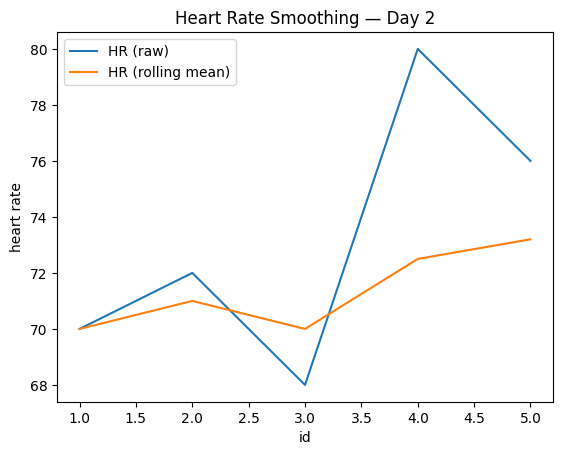

In [5]:
# B5 — Plot raw vs smoothed HR
# Per instruction: use matplotlib only, one chart per plot, no colors specified.
plt.figure()
plt.plot(df['id'], df['hr'], label='HR (raw)')
plt.plot(df['id'], df['hr_smooth'], label='HR (rolling mean)')
plt.legend()
plt.xlabel('id')
plt.ylabel('heart rate')
plt.title('Heart Rate Smoothing — Day 2')
plt.show()

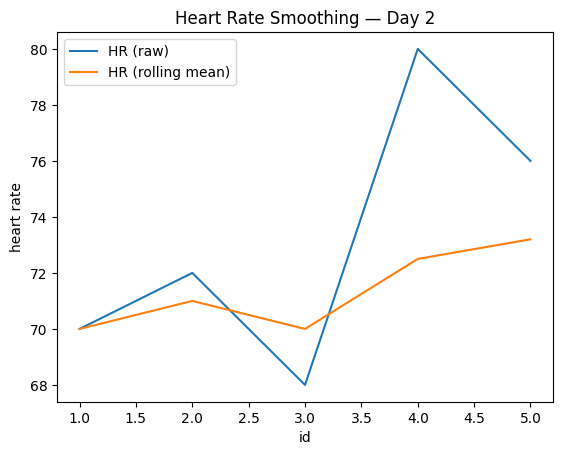

In [6]:
# B6 — Save the plot
import os
os.makedirs('../plots', exist_ok=True)
plt.figure()
plt.plot(df['id'], df['hr'], label='HR (raw)')
plt.plot(df['id'], df['hr_smooth'], label='HR (rolling mean)')
plt.legend()
plt.xlabel('id')
plt.ylabel('heart rate')
plt.title('Heart Rate Smoothing — Day 2')
plt.savefig('../plots/hr_smoothing_day2.png', dpi=300)